In [1]:

import scipy
print(scipy.__version__)

1.13.1


In [6]:
# ============================================================
# Sparse 1D finite-difference radial solver (SciPy eigsh)
# Baseline for Woods–Saxon + Coulomb + spin–orbit
# Solves u(r)=rR(r) with Dirichlet u(0)=u(r_max)=0
# ============================================================

import numpy as np
from time import perf_counter

from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

# ---------------- constants (MeV, fm)
hc = 197.3269804
u  = 931.49410242
e2 = 1.43996448

# ---------------- potential parameters (Schwierz–Wiedenhöver–Volya Table V)
V0_base = 55.2
kappa   = 0.601
R0_par  = 1.22
a       = 0.699
lam_so  = 24.8
R0_so   = 1.13
a_so = a

# ---------------- helpers (NumPy)

def reduced_mass(A: int, is_proton: bool) -> float:
    m_core = float(A - 1) * u
    m_nucl = (
        1.007276466621 * u
        if is_proton
        else 1.00866491588 * u
    )
    return (m_core * m_nucl) / (m_core + m_nucl)


def K_value(mu: float) -> float:
    return (hc**2) / (2.0 * mu)  # MeV·fm^2


def R_central(A: int) -> float:
    return R0_par * (A ** (1.0 / 3.0))


def R_spin_orbit(A: int) -> float:
    return R0_so * (A ** (1.0 / 3.0))


def f_ws(r, R, a_):
    x = np.clip((r - R) / a_, -80.0, 80.0)
    return 1.0 / (1.0 + np.exp(x))


def df_ws_dr(r, R, a_):
    x = np.clip((r - R) / a_, -80.0, 80.0)
    ex = np.exp(x)
    return -(ex / (1.0 + ex) ** 2) * (1.0 / a_)


def tdotT_expectation(
    A: int,
    Z: int,
    is_proton: bool,
) -> float:
    """
    Seminole isospin expectation value:

        -4 <t · T'> = 3,                          N = Z
        -4 <t · T'> = ±(N - Z + 1) + 2,          N > Z
        -4 <t · T'> = ±(N - Z - 1) + 2,          N < Z

    The upper sign is used for protons and the lower sign
    for neutrons.
    """
    N = A - Z

    if N == Z:
        rhs = 3.0

    elif N > Z:
        term = N - Z + 1
        rhs = (term if is_proton else -term) + 2.0

    else:  # N < Z
        term = N - Z - 1
        rhs = (term if is_proton else -term) + 2.0

    return -0.25 * rhs


def V_depth(
    A: int,
    Z: int,
    is_proton: bool,
) -> float:
    """
    Seminole central depth:

        D_tau = V0_base *
                [1 - (4 kappa / A) <t · T'>]
    """
    tdotT = tdotT_expectation(A, Z, is_proton)

    return V0_base * (
        1.0
        - (4.0 * kappa / float(A)) * tdotT
    )


def V_central(
    r,
    A: int,
    Z: int,
    is_proton: bool,
) -> np.ndarray:
    depth = V_depth(A, Z, is_proton)
    R = R_central(A)

    return -depth * f_ws(r, R, a)


def V_coulomb(
    r,
    A: int,
    Z: int,
    is_proton: bool,
) -> np.ndarray:
    if not is_proton:
        return np.zeros_like(r, dtype=float)

    Z_core = max(int(Z) - 1, 0)
    R = R_central(A)

    rc = np.maximum(np.asarray(r, dtype=float), 0.0)
    Vc = np.empty_like(rc)

    inside = rc <= R
    outside = ~inside

    # Uniformly charged sphere inside
    Vc[inside] = (
        Z_core * e2 / (2.0 * R)
    ) * (
        3.0 - (rc[inside] / R) ** 2
    )

    # Point-charge potential outside
    Vc[outside] = (
        Z_core * e2
    ) / rc[outside]

    # Safe value at r = 0
    if rc.size > 0 and rc[0] == 0.0:
        Vc[0] = (
            Z_core * e2 / (2.0 * R)
        ) * 3.0

    return Vc


def l_dot_s(
    l: int,
    j: float,
) -> float:
    return 0.5 * (
        j * (j + 1.0)
        - l * (l + 1.0)
        - 0.75
    )


def V_so(
    r,
    A: int,
    Z: int,
    is_proton: bool,
    l: int,
    j: float,
    mu: float,
) -> np.ndarray:
    """
    Seminole spin-orbit contribution:

        V_SO(r) =
            (hc^2 / (2 mu^2 r))
            d[V_tilde f_SO(r)]/dr
            <l · s>

    with

        V_tilde = lambda_SO * V0_base

    and a_SO = a.
    """
    rc = np.maximum(
        np.asarray(r, dtype=float),
        1e-10,
    )

    Rso = R_spin_orbit(A)

    # Seminole spin-orbit depth
    Vtilde = lam_so * V0_base

    dV_dr = (
        Vtilde
        * df_ws_dr(rc, Rso, a_so)
    )

    prefactor = (
        hc**2
    ) / (
        2.0 * mu**2 * rc
    )

    return (
        prefactor
        * dV_dr
        * float(l_dot_s(l, j))
    )


def V_eff(
    r,
    A: int,
    Z: int,
    is_proton: bool,
    l: int,
    j: float,
) -> np.ndarray:
    mu = reduced_mass(A, is_proton)

    return (
        V_central(
            r,
            A,
            Z,
            is_proton,
        )
        + V_coulomb(
            r,
            A,
            Z,
            is_proton,
        )
        + V_so(
            r,
            A,
            Z,
            is_proton,
            l,
            j,
            mu,
        )
    )
# ============================================================
# Sparse FD eigen solver for radial equation in u(r)
# H = -K d^2/dr^2 + V_eff(r) + K*l(l+1)/r^2
# ============================================================
def fd_radial_spectrum_sparse(
    A: int, Z: int, is_proton: bool,
    l: int, j: float,
    r_max: float = 25.0,
    N: int = 20000,     # grid points including boundaries
    n_eigs: int = 8,    # how many lowest eigenvalues
    which: str = "SA"   # smallest algebraic (captures most negative bound states)
):
    t0 = perf_counter()

    mu = reduced_mass(A, is_proton)
    K  = K_value(mu)

    r = np.linspace(0.0, r_max, N)
    dr = r[1] - r[0]

    # interior points only
    ri = r[1:-1]
    M = ri.size

    V = V_eff(ri, A, Z, is_proton, l, j)
    Vcent = K * (l*(l+1.0)) / (ri**2)
    Vtot = V + Vcent

    main = (2.0*K/(dr**2)) + Vtot
    off  = (-K/(dr**2)) * np.ones(M-1)

    H = diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="csc"
    )

    # eigsh returns k eigenpairs. Use which="SA" for smallest algebraic.
    evals, evecs = eigsh(H, k=n_eigs, which=which, tol=1e-10, maxiter=200000)

    evals = np.sort(evals)
    t1 = perf_counter()

    meta = dict(dr=dr, M=M, mu=mu, K=K, r_max=r_max, N=N)
    return evals, (t1 - t0), meta

# ============================================================
# Quantum number helpers
# ============================================================
def allowed_j(l):
    if l == 0:
        return [0.5]
    return [l - 0.5, l + 0.5]


def build_states(max_l=4, max_nr=3):
    """
    Returns list of (nr, l, j)
    """
    states = []
    for l in range(max_l + 1):
        for j in allowed_j(l):
            for nr in range(max_nr + 1):
                states.append((nr, l, j))
    return states


# ============================================================
# Solve FULL spectrum for nucleus
# ============================================================
def compute_full_spectrum(
    A, Z,
    is_proton,
    max_l=4,
    max_nr=3,
    r_max=25.0,
    N=2000,
    n_eigs=10
):
    results = []

    states = build_states(max_l, max_nr)

    for (nr, l, j) in states:

        E, _, _ = fd_radial_spectrum_sparse(
            A, Z, is_proton,
            l, j,
            r_max=r_max,
            N=N,
            n_eigs=n_eigs
        )

        # keep only bound states (E < 0)
        E_bound = E[E < 0]

        if len(E_bound) == 0:
            continue

        # pick nr-th state if exists
        if nr < len(E_bound):
            results.append({
                "nr": nr,
                "l": l,
                "j": j,
                "energy": float(E_bound[nr])
            })

    return results


# ============================================================
# Save / Load
# ============================================================
def save_spectrum(data, filename):
    np.savez(filename, data=data)


def load_spectrum(filename):
    return np.load(filename, allow_pickle=True)["data"]


def print_spectrum(A, Z, is_proton, states):
    species = "proton" if is_proton else "neutron"

    print(f"\n=== Spectrum A={A} Z={Z} ({species}) ===")

    # sort by energy
    states = sorted(states, key=lambda x: x["energy"])

    for s in states:
        nr = s["nr"]
        l  = s["l"]
        j  = s["j"]
        E  = s["energy"]

        print(f"(nr={nr}, l={l}, j={j:.1f})  ->  E = {E:.4f} MeV")

# ============================================================
# Run for multiple nuclei
# ============================================================
def generate_dataset(
    nuclei,
    max_l=4,
    max_nr=2,
    N=2000
):
    dataset = []

    for (A, Z) in nuclei:
        for is_proton in [False, True]:

            print(f"\nComputing A={A}, Z={Z}, species={'p' if is_proton else 'n'}")

            spec = compute_full_spectrum(
                A, Z,
                is_proton,
                max_l=max_l,
                max_nr=max_nr,
                N=N
            )

            # PRINT HERE
            print_spectrum(A, Z, is_proton, spec)

            dataset.append({
                "A": A,
                "Z": Z,
                "is_proton": is_proton,
                "states": spec
            })

    return dataset


# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":

    nuclei = [
        (208, 82), (56, 28), (132, 50), (100, 50), (40, 20), (48, 20),
        (16, 8), (90, 40) 
    ]

    data = generate_dataset(
        nuclei,
        max_l=8,
        max_nr=3,
        N=2000
    )

    save_spectrum(data, "lsq_dataset.npz")

    print("\nDataset saved: lsq_dataset.npz")


Computing A=208, Z=82, species=n

=== Spectrum A=208 Z=82 (neutron) ===
(nr=0, l=0, j=0.5)  ->  E = -43.7314 MeV
(nr=0, l=1, j=1.5)  ->  E = -39.5327 MeV
(nr=0, l=1, j=0.5)  ->  E = -38.8418 MeV
(nr=0, l=2, j=2.5)  ->  E = -34.6520 MeV
(nr=0, l=2, j=1.5)  ->  E = -33.0537 MeV
(nr=1, l=0, j=0.5)  ->  E = -32.1575 MeV
(nr=0, l=3, j=3.5)  ->  E = -29.1800 MeV
(nr=0, l=3, j=2.5)  ->  E = -26.3708 MeV
(nr=1, l=1, j=1.5)  ->  E = -25.5482 MeV
(nr=1, l=1, j=0.5)  ->  E = -24.5118 MeV
(nr=0, l=4, j=4.5)  ->  E = -23.1718 MeV
(nr=0, l=4, j=3.5)  ->  E = -18.9251 MeV
(nr=1, l=2, j=2.5)  ->  E = -18.6114 MeV
(nr=1, l=2, j=1.5)  ->  E = -16.7555 MeV
(nr=2, l=0, j=0.5)  ->  E = -16.6797 MeV
(nr=0, l=5, j=5.5)  ->  E = -16.6670 MeV
(nr=1, l=3, j=3.5)  ->  E = -11.4544 MeV
(nr=0, l=5, j=4.5)  ->  E = -10.8598 MeV
(nr=0, l=6, j=6.5)  ->  E = -9.7027 MeV
(nr=2, l=1, j=1.5)  ->  E = -9.1772 MeV
(nr=1, l=3, j=2.5)  ->  E = -8.8389 MeV
(nr=2, l=1, j=0.5)  ->  E = -8.2530 MeV
(nr=1, l=4, j=4.5)  ->  E = -

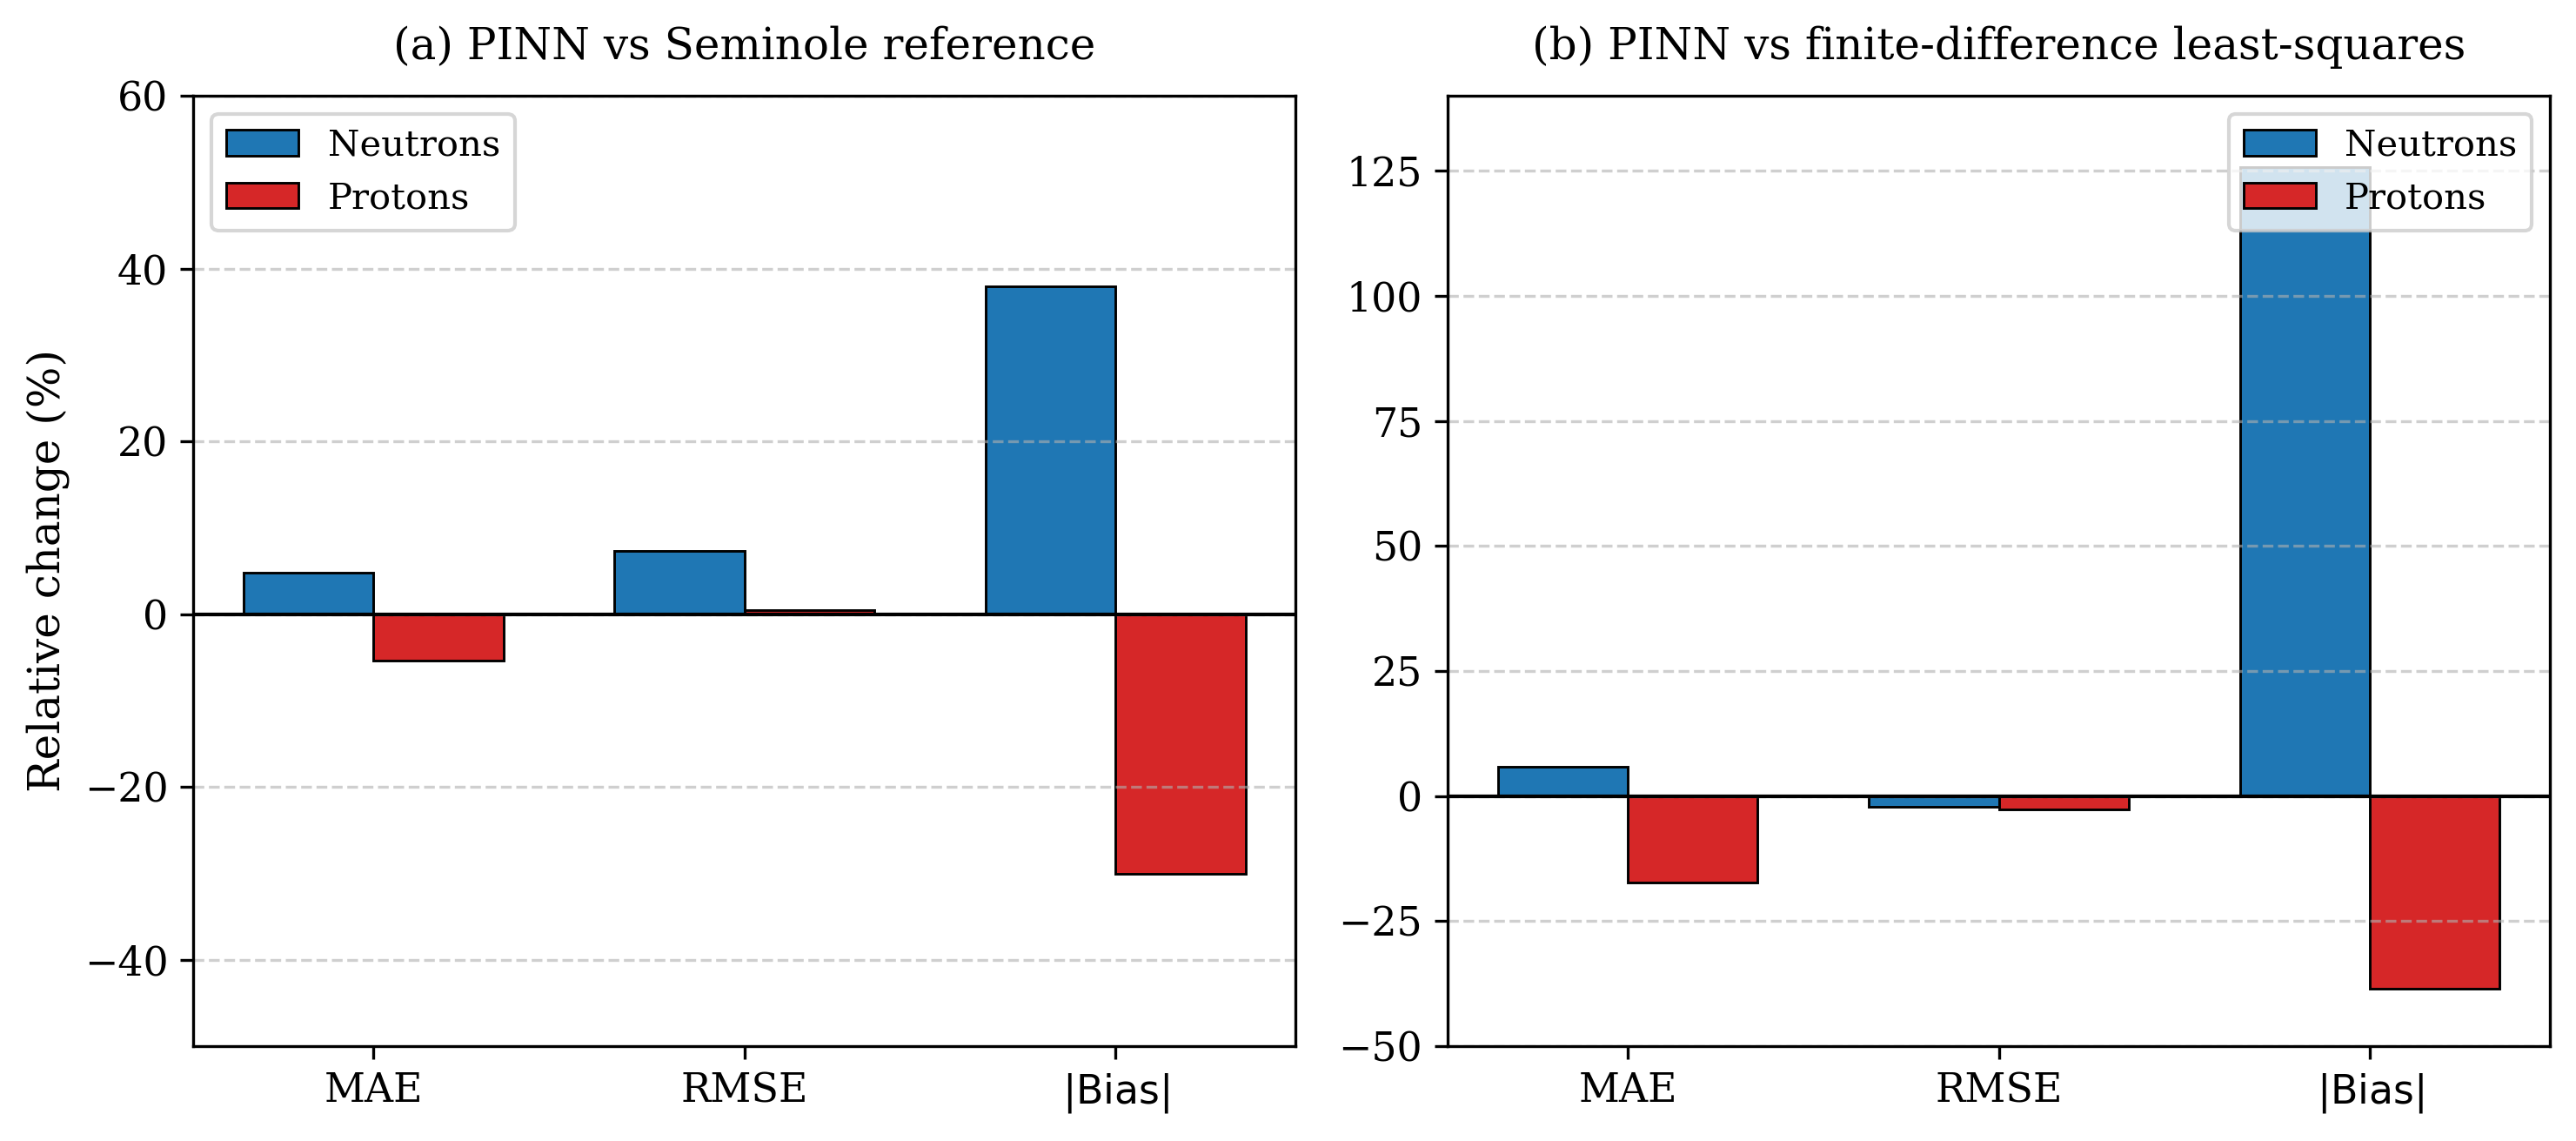

In [ ]:
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')


In [9]:
# ============================================================
# Posterior uncertainty-assisted FD reconstruction
# For global Woods-Saxon parameter uncertainty propagation
# ============================================================

import numpy as np
import pandas as pd
from dataclasses import dataclass, asdict
from pathlib import Path
from copy import deepcopy


NOTEBOOK_DIR = Path(r"C:\Users\INFOLYSiS\Desktop\MSc AI\Thesis\inverse")
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)


def data_path(name: str) -> Path:
    path = Path(name)
    return path if path.is_absolute() else NOTEBOOK_DIR / path


def output_path(name: str) -> Path:
    return data_path(name)


# ============================================================
# Parameter container
# ============================================================
@dataclass
class WSParamSet:
    V0_base: float
    kappa: float
    R0_par: float
    a: float
    lam_so: float
    R0_so: float

    @property
    def a_so(self):
        return self.a


SEMINOLE_PARAMS = WSParamSet(
    V0_base=51,
    kappa=0.67,
    R0_par=1.27,
    a=0.67,
    lam_so=32,
    R0_so=1.27,
)

PINN_MEAN_PARAMS = WSParamSet(
    V0_base = 52.45,
    kappa   = 0.632,
    R0_par  = 1.26,
    a       = 0.654,
    lam_so  = 26.16,
    R0_so   = 1.19,
)

PINN_SIGMA_PARAMS = WSParamSet(
    V0_base=0.011,
    kappa=0.001,
    R0_par=0.0002,
    a=0.001,
    lam_so=0.06,
    R0_so=0.001,
)


PARAM_BOUNDS = {
    "V0_base": (40.0, 65.0),
    "kappa": (0.30, 1.00),
    "R0_par": (1.15, 1.35),
    "a": (0.55, 0.75),
    "lam_so": (15.0, 35.0),
    "R0_so": (1.05, 1.30),
}


# ============================================================
# Load experimental dataset
# ============================================================
def load_experimental_dataset(path="experimental_dataset.npz"):
    full_path = data_path(path)
    raw = np.load(full_path, allow_pickle=True)["data"]
    return list(raw)


def iter_experimental_states(dataset, exclude_16O=True):
    """
    Flatten experimental dataset into one row per state.

    Returns rows with:
        A, Z, is_proton, species, nr, l, j, E_exp
    """
    rows = []

    for item in dataset:
        A = int(item["A"])
        Z = int(item["Z"])
        is_proton = bool(item["is_proton"])

        if exclude_16O and A == 16:
            continue

        species = "p" if is_proton else "n"

        for st in item["states"]:
            rows.append({
                "A": A,
                "Z": Z,
                "is_proton": is_proton,
                "species": species,
                "nr": int(st["nr"]),
                "l": int(st["l"]),
                "j": float(st["j"]),
                "E_exp": float(st["energy"]),
            })

    return rows


def state_key(row):
    return (
        int(row["A"]),
        int(row["Z"]),
        bool(row["is_proton"]),
        int(row["nr"]),
        int(row["l"]),
        round(float(row["j"]), 6),
    )


# ============================================================
# Apply parameter set to your existing FD solver globals
# ============================================================
def set_fd_global_params(params: WSParamSet):
    """
    Your FD solver currently uses global variables:
        V0_base, kappa, R0_par, a, lam_so, R0_so, a_so

    This function overwrites them before each FD reconstruction.
    """
    global V0_base, kappa, R0_par, a, lam_so, R0_so, a_so

    V0_base = float(params.V0_base)
    kappa = float(params.kappa)
    R0_par = float(params.R0_par)
    a = float(params.a)
    lam_so = float(params.lam_so)
    R0_so = float(params.R0_so)
    a_so = float(params.a_so)


# ============================================================
# FD reconstruction for matched experimental states
# ============================================================
def reconstruct_matched_fd_energies(
    exp_rows,
    params: WSParamSet,
    r_max=25.0,
    N=2000,
    n_eigs=12,
):
    """
    For each experimental state, run the FD radial solver with the same
    (A, Z, species, l, j), then select the nr-th bound state.

    Matching is by:
        (A, Z, is_proton, nr, l, j)

    This does NOT compare by sorted global energy order.
    """
    set_fd_global_params(params)

    output_rows = []

    # Cache FD spectra by channel to avoid recomputing the same (A,Z,species,l,j)
    spectrum_cache = {}

    for row in exp_rows:
        A = int(row["A"])
        Z = int(row["Z"])
        is_proton = bool(row["is_proton"])
        nr = int(row["nr"])
        l = int(row["l"])
        j = float(row["j"])

        channel_key = (A, Z, is_proton, l, round(j, 6))

        if channel_key not in spectrum_cache:
            evals, _, meta = fd_radial_spectrum_sparse(
                A=A,
                Z=Z,
                is_proton=is_proton,
                l=l,
                j=j,
                r_max=r_max,
                N=N,
                n_eigs=n_eigs,
                which="SA",
            )

            E_bound = np.array(evals[evals < 0.0], dtype=float)
            E_bound = np.sort(E_bound)

            spectrum_cache[channel_key] = E_bound

        E_bound = spectrum_cache[channel_key]

        if nr >= len(E_bound):
            # No matched FD bound state exists.
            # This can happen for weakly bound/unbound experimental states.
            continue

        E_fd = float(E_bound[nr])
        E_exp = float(row["E_exp"])

        new_row = dict(row)
        new_row["E_fd"] = E_fd
        new_row["error"] = E_fd - E_exp

        output_rows.append(new_row)

    return pd.DataFrame(output_rows)


# ============================================================
# Metrics
# ============================================================
def compute_metrics_from_df(df):
    if len(df) == 0:
        return {
            "N": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "R2": np.nan,
        }

    e = df["error"].to_numpy(dtype=float)
    y = df["E_exp"].to_numpy(dtype=float)
    yhat = df["E_fd"].to_numpy(dtype=float)

    mae = np.mean(np.abs(e))
    rmse = np.sqrt(np.mean(e**2))
    bias = np.mean(e)

    denom = np.sum((y - np.mean(y))**2)
    if denom <= 0:
        r2 = np.nan
    else:
        r2 = 1.0 - np.sum((yhat - y)**2) / denom

    return {
        "N": int(len(df)),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Bias": float(bias),
        "R2": float(r2),
    }


def compute_all_metric_groups(df):
    """
    Computes:
        all
        neutrons
        protons
        excluding 48Ca neutrons
        only 48Ca neutrons
        by nucleus/species
    """
    results = {}

    results["all"] = compute_metrics_from_df(df)
    results["neutrons"] = compute_metrics_from_df(df[df["is_proton"] == False])
    results["protons"] = compute_metrics_from_df(df[df["is_proton"] == True])

    mask_48ca_n = (
        (df["A"] == 48)
        & (df["Z"] == 20)
        & (df["is_proton"] == False)
    )

    results["without_48Ca_neutrons"] = compute_metrics_from_df(df[~mask_48ca_n])
    results["only_48Ca_neutrons"] = compute_metrics_from_df(df[mask_48ca_n])

    by_group = []

    for (A, Z, is_proton), g in df.groupby(["A", "Z", "is_proton"]):
        species = "p" if bool(is_proton) else "n"
        m = compute_metrics_from_df(g)
        m["group"] = f"{int(A)}{species}"
        m["A"] = int(A)
        m["Z"] = int(Z)
        m["is_proton"] = bool(is_proton)
        by_group.append(m)

    results["by_nucleus_species"] = pd.DataFrame(by_group)

    return results


def metrics_dict_to_dataframe(metrics_dict, method_name):
    rows = []

    for group_name in [
        "all",
        "neutrons",
        "protons",
        "without_48Ca_neutrons",
        "only_48Ca_neutrons",
    ]:
        row = dict(metrics_dict[group_name])
        row["method"] = method_name
        row["group"] = group_name
        rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# Parameter sampling
# ============================================================
def clip_param_value(name, value):
    lo, hi = PARAM_BOUNDS[name]
    return float(np.clip(value, lo, hi))


def sample_physical_gaussian_params(
    mean_params: WSParamSet,
    sigma_params: WSParamSet,
    n_samples=500,
    temperature=1.0,
    seed=0,
):
    """
    Physical-space Gaussian approximation:

        theta_i ~ Normal(mu_i, (T sigma_i)^2)

    Then samples are clipped to the Woods-Saxon parameter bounds.
    """
    rng = np.random.default_rng(seed)

    samples = []

    mean_dict = asdict(mean_params)
    sigma_dict = asdict(sigma_params)

    for _ in range(n_samples):
        p = {}

        for name in ["V0_base", "kappa", "R0_par", "a", "lam_so", "R0_so"]:
            mu = float(mean_dict[name])
            sig = float(sigma_dict[name]) * float(temperature)
            value = rng.normal(mu, sig)
            p[name] = clip_param_value(name, value)

        samples.append(WSParamSet(**p))

    return samples


# ============================================================
# Posterior ensemble reconstruction
# ============================================================
def run_posterior_fd_ensemble(
    exp_rows,
    mean_params: WSParamSet,
    sigma_params: WSParamSet,
    n_samples=500,
    temperature=1.0,
    seed=0,
    r_max=25.0,
    N=2000,
    n_eigs=12,
    verbose=True,
):
    """
    Runs FD reconstruction for many posterior parameter samples.

    Returns:
        sample_params_df
        sample_metrics_df
        energy_ensemble_df
    """

    param_samples = sample_physical_gaussian_params(
        mean_params=mean_params,
        sigma_params=sigma_params,
        n_samples=n_samples,
        temperature=temperature,
        seed=seed,
    )

    sample_param_rows = []
    sample_metric_rows = []
    energy_rows = []

    for s, params in enumerate(param_samples):
        if verbose and (s == 0 or (s + 1) % 50 == 0 or s == n_samples - 1):
            print(
                f"T={temperature:.2f} | posterior sample "
                f"{s + 1}/{n_samples}"
            )

        df_s = reconstruct_matched_fd_energies(
            exp_rows=exp_rows,
            params=params,
            r_max=r_max,
            N=N,
            n_eigs=n_eigs,
        )

        metrics_s = compute_all_metric_groups(df_s)

        param_row = asdict(params)
        param_row["sample_id"] = s
        param_row["temperature"] = temperature
        sample_param_rows.append(param_row)

        for group_name in [
            "all",
            "neutrons",
            "protons",
            "without_48Ca_neutrons",
            "only_48Ca_neutrons",
        ]:
            m = dict(metrics_s[group_name])
            m["sample_id"] = s
            m["temperature"] = temperature
            m["group"] = group_name
            sample_metric_rows.append(m)

        for _, row in df_s.iterrows():
            energy_rows.append({
                "sample_id": s,
                "temperature": temperature,
                "A": int(row["A"]),
                "Z": int(row["Z"]),
                "is_proton": bool(row["is_proton"]),
                "species": row["species"],
                "nr": int(row["nr"]),
                "l": int(row["l"]),
                "j": float(row["j"]),
                "E_exp": float(row["E_exp"]),
                "E_fd": float(row["E_fd"]),
                "error": float(row["error"]),
            })

    sample_params_df = pd.DataFrame(sample_param_rows)
    sample_metrics_df = pd.DataFrame(sample_metric_rows)
    energy_ensemble_df = pd.DataFrame(energy_rows)

    return sample_params_df, sample_metrics_df, energy_ensemble_df


# ============================================================
# Posterior-predictive mean spectrum
# ============================================================
def posterior_predictive_mean_df(energy_ensemble_df):
    """
    Computes:

        E_bar_k = mean_s E_k(theta_s)
        sigma_E_k = std_s E_k(theta_s)

    for each matched state.
    """
    key_cols = ["A", "Z", "is_proton", "species", "nr", "l", "j"]

    grouped = energy_ensemble_df.groupby(key_cols)

    rows = []

    for key, g in grouped:
        E_exp = float(g["E_exp"].iloc[0])
        E_mean = float(g["E_fd"].mean())
        E_std = float(g["E_fd"].std(ddof=1)) if len(g) > 1 else 0.0

        row = dict(zip(key_cols, key))
        row["E_exp"] = E_exp
        row["E_fd"] = E_mean
        row["E_fd_std"] = E_std
        row["error"] = E_mean - E_exp

        if E_std > 0:
            row["z_residual"] = (E_exp - E_mean) / E_std
        else:
            row["z_residual"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# Best posterior sample and top-K posterior average
# ============================================================
def select_best_sample(
    sample_metrics_df,
    group="all",
    selection_metric="MAE",
):
    """
    Selects best posterior sample based on a metric group.
    For a rigorous study, use this on validation data only.
    """
    sub = sample_metrics_df[sample_metrics_df["group"] == group].copy()
    sub = sub.sort_values(selection_metric, ascending=True)

    best = sub.iloc[0]

    return int(best["sample_id"]), float(best[selection_metric])


def best_sample_prediction_df(energy_ensemble_df, sample_id):
    df = energy_ensemble_df[energy_ensemble_df["sample_id"] == sample_id].copy()
    return df.reset_index(drop=True)


def topk_posterior_average_df(
    energy_ensemble_df,
    sample_metrics_df,
    k=25,
    group="all",
    selection_metric="MAE",
):
    """
    Selects top-K samples by validation metric and averages their energies.
    """
    sub = sample_metrics_df[sample_metrics_df["group"] == group].copy()
    sub = sub.sort_values(selection_metric, ascending=True)

    top_ids = sub["sample_id"].head(k).astype(int).tolist()

    top_energy = energy_ensemble_df[
        energy_ensemble_df["sample_id"].isin(top_ids)
    ].copy()

    pp_topk = posterior_predictive_mean_df(top_energy)
    pp_topk["top_k"] = int(k)

    return pp_topk, top_ids


# ============================================================
# Temperature scaling experiment
# ============================================================
def run_temperature_experiment(
    exp_rows,
    mean_params: WSParamSet,
    sigma_params: WSParamSet,
    temperatures=(0.25, 0.5, 0.75, 1.0, 1.5),
    n_samples=300,
    seed=0,
    r_max=25.0,
    N=2000,
    n_eigs=12,
    out_prefix="posterior_temperature",
):
    all_param_dfs = []
    all_metric_dfs = []
    all_energy_dfs = []
    pp_metric_rows = []

    for T in temperatures:
        sample_params_df, sample_metrics_df, energy_ensemble_df = (
            run_posterior_fd_ensemble(
                exp_rows=exp_rows,
                mean_params=mean_params,
                sigma_params=sigma_params,
                n_samples=n_samples,
                temperature=T,
                seed=seed,
                r_max=r_max,
                N=N,
                n_eigs=n_eigs,
                verbose=True,
            )
        )

        pp_df = posterior_predictive_mean_df(energy_ensemble_df)
        pp_metrics = compute_all_metric_groups(pp_df)

        pp_metric_df = metrics_dict_to_dataframe(
            pp_metrics,
            method_name=f"posterior_predictive_T={T}",
        )
        pp_metric_df["temperature"] = T

        pp_metric_rows.append(pp_metric_df)

        all_param_dfs.append(sample_params_df)
        all_metric_dfs.append(sample_metrics_df)
        all_energy_dfs.append(energy_ensemble_df)

    all_params = pd.concat(all_param_dfs, ignore_index=True)
    all_sample_metrics = pd.concat(all_metric_dfs, ignore_index=True)
    all_energies = pd.concat(all_energy_dfs, ignore_index=True)
    all_pp_metrics = pd.concat(pp_metric_rows, ignore_index=True)

    all_params.to_csv(output_path(f"{out_prefix}_params.csv"), index=False)
    all_sample_metrics.to_csv(output_path(f"{out_prefix}_sample_metrics.csv"), index=False)
    all_energies.to_csv(output_path(f"{out_prefix}_energies.csv"), index=False)
    all_pp_metrics.to_csv(output_path(f"{out_prefix}_posterior_predictive_metrics.csv"), index=False)

    return all_params, all_sample_metrics, all_energies, all_pp_metrics


# ============================================================
# Baseline comparison: Seminole vs PINN mean
# ============================================================
def run_baseline_comparison(
    exp_rows,
    r_max=25.0,
    N=2000,
    n_eigs=12,
):
    seminole_df = reconstruct_matched_fd_energies(
        exp_rows=exp_rows,
        params=SEMINOLE_PARAMS,
        r_max=r_max,
        N=N,
        n_eigs=n_eigs,
    )

    pinn_mean_df = reconstruct_matched_fd_energies(
        exp_rows=exp_rows,
        params=PINN_MEAN_PARAMS,
        r_max=r_max,
        N=N,
        n_eigs=n_eigs,
    )

    seminole_metrics = compute_all_metric_groups(seminole_df)
    pinn_mean_metrics = compute_all_metric_groups(pinn_mean_df)

    metrics_table = pd.concat(
        [
            metrics_dict_to_dataframe(seminole_metrics, "Seminole"),
            metrics_dict_to_dataframe(pinn_mean_metrics, "PINN_mean"),
        ],
        ignore_index=True,
    )

    seminole_df.to_csv(output_path("baseline_seminole_state_errors.csv"), index=False)
    pinn_mean_df.to_csv(output_path("baseline_pinn_mean_state_errors.csv"), index=False)
    metrics_table.to_csv(output_path("baseline_metrics.csv"), index=False)

    return seminole_df, pinn_mean_df, metrics_table


# ============================================================
# Sensitivity analysis
# ============================================================
def perturb_param(params: WSParamSet, name, delta):
    p = asdict(params)
    p[name] = clip_param_value(name, p[name] + delta)
    return WSParamSet(**p)


def finite_difference_sensitivity(
    exp_rows,
    base_params: WSParamSet,
    sigma_params: WSParamSet,
    step_scale=1.0,
    r_max=25.0,
    N=2000,
    n_eigs=12,
):
    """
    Computes central finite-difference sensitivity:

        S_{k,i} = [E_k(theta_i + Delta_i) - E_k(theta_i - Delta_i)] / (2 Delta_i)

    and uncertainty-weighted sensitivity:

        U_{k,i} = |S_{k,i}| sigma_i
    """
    param_names = ["V0_base", "kappa", "R0_par", "a", "lam_so", "R0_so"]

    sigma_dict = asdict(sigma_params)

    sensitivity_rows = []

    base_df = reconstruct_matched_fd_energies(
        exp_rows=exp_rows,
        params=base_params,
        r_max=r_max,
        N=N,
        n_eigs=n_eigs,
    )

    base_map = {
        state_key(row): row
        for _, row in base_df.iterrows()
    }

    for name in param_names:
        sigma_i = float(sigma_dict[name])
        delta = float(step_scale) * sigma_i

        if delta <= 0:
            continue

        params_plus = perturb_param(base_params, name, +delta)
        params_minus = perturb_param(base_params, name, -delta)

        df_plus = reconstruct_matched_fd_energies(
            exp_rows=exp_rows,
            params=params_plus,
            r_max=r_max,
            N=N,
            n_eigs=n_eigs,
        )

        df_minus = reconstruct_matched_fd_energies(
            exp_rows=exp_rows,
            params=params_minus,
            r_max=r_max,
            N=N,
            n_eigs=n_eigs,
        )

        plus_map = {
            state_key(row): row
            for _, row in df_plus.iterrows()
        }

        minus_map = {
            state_key(row): row
            for _, row in df_minus.iterrows()
        }

        common_keys = set(base_map.keys()) & set(plus_map.keys()) & set(minus_map.keys())

        for key in common_keys:
            row_base = base_map[key]
            row_plus = plus_map[key]
            row_minus = minus_map[key]

            E_plus = float(row_plus["E_fd"])
            E_minus = float(row_minus["E_fd"])

            S_ki = (E_plus - E_minus) / (2.0 * delta)
            U_ki = abs(S_ki) * sigma_i

            sensitivity_rows.append({
                "A": int(row_base["A"]),
                "Z": int(row_base["Z"]),
                "is_proton": bool(row_base["is_proton"]),
                "species": row_base["species"],
                "nr": int(row_base["nr"]),
                "l": int(row_base["l"]),
                "j": float(row_base["j"]),
                "E_exp": float(row_base["E_exp"]),
                "E_base": float(row_base["E_fd"]),
                "param": name,
                "sigma_param": sigma_i,
                "delta_used": delta,
                "dE_dtheta": float(S_ki),
                "U_abs": float(U_ki),
            })

    sens_df = pd.DataFrame(sensitivity_rows)

    return sens_df


def summarize_sensitivity_by_group(sens_df):
    rows = []

    for (A, Z, is_proton, param), g in sens_df.groupby(
        ["A", "Z", "is_proton", "param"]
    ):
        species = "p" if bool(is_proton) else "n"

        rows.append({
            "A": int(A),
            "Z": int(Z),
            "is_proton": bool(is_proton),
            "group": f"{int(A)}{species}",
            "param": param,
            "mean_U_abs": float(g["U_abs"].mean()),
            "max_U_abs": float(g["U_abs"].max()),
            "mean_abs_dE_dtheta": float(np.abs(g["dE_dtheta"]).mean()),
            "N": int(len(g)),
        })

    return pd.DataFrame(rows)


# ============================================================
# Full workflow
# ============================================================
def run_uncertainty_assisted_reconstruction(
    dataset_path="experimental_dataset.npz",
    exclude_16O=True,
    n_samples=300,
    temperatures=(0.25, 0.5, 0.75, 1.0, 1.5),
    seed=0,
    r_max=25.0,
    N=2000,
    n_eigs=12,
):
    dataset = load_experimental_dataset(dataset_path)
    exp_rows = iter_experimental_states(dataset, exclude_16O=exclude_16O)

    print(f"Loaded {len(exp_rows)} experimental states.")
    print(f"exclude_16O = {exclude_16O}")

    # --------------------------------------------------------
    # 1. Baselines
    # --------------------------------------------------------
    print("\nRunning Seminole and PINN-mean baselines...")

    seminole_df, pinn_mean_df, baseline_metrics = run_baseline_comparison(
        exp_rows=exp_rows,
        r_max=r_max,
        N=N,
        n_eigs=n_eigs,
    )

    print("\nBaseline metrics:")
    display(baseline_metrics)

    # --------------------------------------------------------
    # 2. Temperature-scaled posterior ensemble
    # --------------------------------------------------------
    print("\nRunning posterior ensemble temperature experiment...")

    all_params, all_sample_metrics, all_energies, all_pp_metrics = (
        run_temperature_experiment(
            exp_rows=exp_rows,
            mean_params=PINN_MEAN_PARAMS,
            sigma_params=PINN_SIGMA_PARAMS,
            temperatures=temperatures,
            n_samples=n_samples,
            seed=seed,
            r_max=r_max,
            N=N,
            n_eigs=n_eigs,
            out_prefix="posterior_temperature",
        )
    )

    print("\nPosterior-predictive metrics:")
    display(all_pp_metrics)

    # --------------------------------------------------------
    # 3. Best sample and top-K for each temperature
    # --------------------------------------------------------
    best_rows = []
    topk_rows = []

    for T in temperatures:
        sample_metrics_T = all_sample_metrics[
            all_sample_metrics["temperature"] == T
        ].copy()

        energy_T = all_energies[
            all_energies["temperature"] == T
        ].copy()

        best_id, best_mae = select_best_sample(
            sample_metrics_df=sample_metrics_T,
            group="all",
            selection_metric="MAE",
        )

        best_df = best_sample_prediction_df(
            energy_ensemble_df=energy_T,
            sample_id=best_id,
        )

        best_metrics = compute_all_metric_groups(best_df)
        best_metrics_df = metrics_dict_to_dataframe(
            best_metrics,
            method_name=f"best_sample_T={T}_id={best_id}",
        )
        best_metrics_df["temperature"] = T
        best_metrics_df["sample_id"] = best_id

        best_rows.append(best_metrics_df)

        for K in [5, 10, 25, 50]:
            if K > n_samples:
                continue

            topk_df, top_ids = topk_posterior_average_df(
                energy_ensemble_df=energy_T,
                sample_metrics_df=sample_metrics_T,
                k=K,
                group="all",
                selection_metric="MAE",
            )

            topk_metrics = compute_all_metric_groups(topk_df)
            topk_metrics_df = metrics_dict_to_dataframe(
                topk_metrics,
                method_name=f"top{K}_average_T={T}",
            )
            topk_metrics_df["temperature"] = T
            topk_metrics_df["top_k"] = K

            topk_rows.append(topk_metrics_df)

    best_metrics_all = pd.concat(best_rows, ignore_index=True)
    topk_metrics_all = pd.concat(topk_rows, ignore_index=True)

    best_metrics_all.to_csv(output_path("best_posterior_sample_metrics.csv"), index=False)
    topk_metrics_all.to_csv(output_path("topk_posterior_average_metrics.csv"), index=False)

    print("\nBest posterior sample metrics:")
    display(best_metrics_all)

    print("\nTop-K posterior average metrics:")
    display(topk_metrics_all)

    # --------------------------------------------------------
    # 4. Sensitivity analysis around PINN mean
    # --------------------------------------------------------
    print("\nRunning finite-difference sensitivity analysis...")

    sens_df = finite_difference_sensitivity(
        exp_rows=exp_rows,
        base_params=PINN_MEAN_PARAMS,
        sigma_params=PINN_SIGMA_PARAMS,
        step_scale=1.0,
        r_max=r_max,
        N=N,
        n_eigs=n_eigs,
    )

    sens_summary = summarize_sensitivity_by_group(sens_df)

    sens_df.to_csv(output_path("parameter_sensitivity_statewise.csv"), index=False)
    sens_summary.to_csv(output_path("parameter_sensitivity_by_group.csv"), index=False)

    print("\nSensitivity summary:")
    display(sens_summary)

    return {
        "exp_rows": exp_rows,
        "seminole_df": seminole_df,
        "pinn_mean_df": pinn_mean_df,
        "baseline_metrics": baseline_metrics,
        "posterior_params": all_params,
        "posterior_sample_metrics": all_sample_metrics,
        "posterior_energies": all_energies,
        "posterior_predictive_metrics": all_pp_metrics,
        "best_metrics": best_metrics_all,
        "topk_metrics": topk_metrics_all,
        "sensitivity_statewise": sens_df,
        "sensitivity_summary": sens_summary,
    }


In [12]:
results = run_uncertainty_assisted_reconstruction(
    dataset_path="experimental_dataset.npz",
    exclude_16O=False,
    n_samples=50,
    temperatures=(0.5, 1.0),
    seed=0,
    r_max=25.0,
    N=2000,
    n_eigs=12,
)

Loaded 96 experimental states.
exclude_16O = False

Running Seminole and PINN-mean baselines...

Baseline metrics:


,N,MAE,RMSE,Bias,R2,method,group
0,94,1.078300,1.411347,0.842879,0.930957,Seminole,all
1,59,1.010104,1.294444,0.783734,0.941655,Seminole,neutrons
2,35,1.193259,1.589060,0.942580,0.911963,Seminole,protons
3,87,1.100092,1.431698,0.920934,0.929402,Seminole,without_48Ca_neutrons
4,7,0.807454,1.128185,-0.127238,0.952035,Seminole,only_48Ca_neutrons
5,95,0.830629,1.104046,0.202395,0.958251,PINN_mean,all
6,60,0.776291,1.029856,0.084799,0.963851,PINN_mean,neutrons
7,35,0.923779,1.220785,0.403990,0.948041,PINN_mean,protons
8,88,0.789271,1.059048,0.290506,0.961855,PINN_mean,without_48Ca_neutrons
9,7,1.350561,1.562871,-0.905276,0.907953,PINN_mean,only_48Ca_neutrons



Running posterior ensemble temperature experiment...
T=0.50 | posterior sample 1/50
T=0.50 | posterior sample 50/50
T=1.00 | posterior sample 1/50
T=1.00 | posterior sample 50/50

Posterior-predictive metrics:


,N,MAE,RMSE,Bias,R2,method,group,temperature
0,95,0.830447,1.103837,0.202836,0.958267,posterior_predictive_T=0.5,all,0.5
1,60,0.776289,1.029795,0.085781,0.963855,posterior_predictive_T=0.5,neutrons,0.5
2,35,0.923290,1.220359,0.403503,0.948077,posterior_predictive_T=0.5,protons,0.5
3,88,0.789105,1.058854,0.290900,0.961869,posterior_predictive_T=0.5,without_48Ca_neutrons,0.5
4,7,1.350171,1.562517,-0.904257,0.907994,posterior_predictive_T=0.5,only_48Ca_neutrons,0.5
5,95,0.830265,1.103629,0.203274,0.958283,posterior_predictive_T=1.0,all,1.0
6,60,0.776287,1.029737,0.086760,0.963859,posterior_predictive_T=1.0,neutrons,1.0
7,35,0.922799,1.219933,0.403013,0.948113,posterior_predictive_T=1.0,protons,1.0
8,88,0.788939,1.058661,0.291292,0.961882,posterior_predictive_T=1.0,without_48Ca_neutrons,1.0
9,7,1.349785,1.562167,-0.903242,0.908036,posterior_predictive_T=1.0,only_48Ca_neutrons,1.0



Best posterior sample metrics:


,N,MAE,RMSE,Bias,R2,method,group,temperature,sample_id
0,95,0.828737,1.100357,0.188813,0.958530,best_sample_T=0.5_id=11,all,0.5,11
1,60,0.775118,1.027434,0.075656,0.964021,best_sample_T=0.5_id=11,neutrons,0.5,11
2,35,0.920656,1.215229,0.382798,0.948513,best_sample_T=0.5_id=11,protons,0.5,11
3,88,0.786874,1.054257,0.276468,0.962199,best_sample_T=0.5_id=11,without_48Ca_neutrons,0.5,11
4,7,1.355020,1.568264,-0.913129,0.907316,best_sample_T=0.5_id=11,only_48Ca_neutrons,0.5,11
5,95,0.826926,1.096896,0.175214,0.958790,best_sample_T=1.0_id=11,all,1.0,11
6,60,0.773943,1.025128,0.066499,0.964182,best_sample_T=1.0_id=11,neutrons,1.0,11
7,35,0.917754,1.210064,0.361582,0.948949,best_sample_T=1.0_id=11,protons,1.0,11
8,88,0.784563,1.049710,0.262412,0.962524,best_sample_T=1.0_id=11,without_48Ca_neutrons,1.0,11
9,7,1.359490,1.573703,-0.920996,0.906672,best_sample_T=1.0_id=11,only_48Ca_neutrons,1.0,11



Top-K posterior average metrics:


,N,MAE,RMSE,Bias,R2,method,group,temperature,top_k
0,95,0.829103,1.101096,0.190440,0.958474,top5_average_T=0.5,all,0.5,5
1,60,0.775464,1.028164,0.075810,0.963969,top5_average_T=0.5,neutrons,0.5,5
2,35,0.921056,1.215988,0.386949,0.948448,top5_average_T=0.5,protons,0.5,5
3,88,0.787215,1.055106,0.278230,0.962138,top5_average_T=0.5,without_48Ca_neutrons,0.5,5
4,7,1.355705,1.568138,-0.913210,0.907331,top5_average_T=0.5,only_48Ca_neutrons,0.5,5
5,95,0.829326,1.101798,0.195208,0.958421,top10_average_T=0.5,all,0.5,10
6,60,0.775321,1.028255,0.080774,0.963963,top10_average_T=0.5,neutrons,0.5,10
7,35,0.921906,1.217580,0.391379,0.948313,top10_average_T=0.5,protons,0.5,10
8,88,0.787717,1.056249,0.282991,0.962056,top10_average_T=0.5,without_48Ca_neutrons,0.5,10
9,7,1.352409,1.565153,-0.908357,0.907684,top10_average_T=0.5,only_48Ca_neutrons,0.5,10



Running finite-difference sensitivity analysis...

Sensitivity summary:


,A,Z,is_proton,group,param,mean_U_abs,max_U_abs,mean_abs_dE_dtheta,N
0,16,8,False,16n,R0_par,6.075439e-03,7.131995e-03,3.037719e+01,3
1,16,8,False,16n,R0_so,1.605656e-03,3.876321e-03,1.605656e+00,3
2,16,8,False,16n,V0_base,5.506474e-03,6.437932e-03,5.005885e-01,3
3,16,8,False,16n,a,4.623592e-03,5.252901e-03,4.623592e+00,3
4,16,8,False,16n,kappa,5.875522e-12,7.488232e-12,5.875522e-09,3
...,...,...,...,...,...,...,...,...,...
85,208,82,True,208p,R0_so,4.826843e-03,1.172893e-02,4.826843e+00,10
86,208,82,True,208p,V0_base,1.035517e-02,1.096244e-02,9.413793e-01,10
87,208,82,True,208p,a,7.477203e-03,1.326775e-02,7.477203e+00,10
88,208,82,True,208p,kappa,9.213068e-03,9.753362e-03,9.213068e+00,10
